# Week 22: Audit transfer before calling it a foundation model

Does source training improve target dynamics after matching labels, representation and optimizer budget?

**Prerequisites:** Week 7.4 already introduces diverse pretraining. This capstone audits mechanisms and claims rather than repeating that introduction.

Allow 120 minutes plus the written analysis. Instructor solution edition.

In [1]:
from pathlib import Path
import sys, tempfile, json
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'flowmllab/transformer_course.py').exists()),None)
if ROOT is None:
    raise RuntimeError('Extract the supplied course bundle and start Jupyter in its root; see docs/TRANSFORMER_COURSE.md for Colab upload setup.')
sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from flowmllab import transformer_course as lab
lab.seed_all(17)
cases,input_manifest=lab.load_data(ROOT)
EVIDENCE=ROOT/'results/transformer_course_v3'
# Any optional experiment must write into this disposable workspace.
workspace=tempfile.TemporaryDirectory(prefix='flowmllab-student-')
RUN_OUTPUT=Path(workspace.name)
task_status={}
print('Loaded checksummed simulated wake fields. No retained files will be rewritten.')


Loaded checksummed simulated wake fields. No retained files will be rewritten.


In [2]:
RUN_EXERCISES=True

## Count every target label and fix the forecast start

Budgets name ten-frame blocks, not deceptively small counts of training-only labels. The total includes validation frames and four observed initialization frames. All arms forecast frames 160:281 and are scored on 210:281. The three targets were inspected in prior course work.

In [3]:
for blocks in (4,8,15):
    train,val,labels=lab.transfer_indices(blocks)
    print(blocks,'blocks:',len(labels['training_frames']),'training +',len(labels['validation_frames']),'validation +',len(labels['initialization_frames']),'initialization =',labels['total_target_labels'])
record=json.loads((EVIDENCE/'transfer.json').read_text())
rows=record['rows'];display(pd.DataFrame([{'Re':r['target_re'],'labels':r['labels']['total_target_labels'],'arm':r['arm'],'seed':r['seed'],'field':r['metrics']['field_relative_l2'],'floor':r['metrics']['representation_floor'],'subspace':r['metrics']['in_subspace_relative_l2'],'steps':r.get('total_optimizer_steps')} for r in rows]))

4 blocks: 30 training + 10 validation + 4 initialization = 44
8 blocks: 60 training + 20 validation + 4 initialization = 84
15 blocks: 120 training + 30 validation + 4 initialization = 154


,Re,labels,arm,seed,field,floor,subspace,steps
0,100,44,scratch,17,0.963946,0.147758,0.952555,300.0
1,100,44,pretrained,17,0.408994,0.147758,0.381370,600.0
2,100,44,matched-steps,17,0.963946,0.147758,0.952555,600.0
3,100,44,target-POD-MLP,17,0.973617,0.538693,0.811012,300.0
4,100,44,DMD,17,1.151185,0.147758,1.141663,NaN
...,...,...,...,...,...,...,...,...
130,110,154,scratch,43,0.292208,0.255875,0.141115,300.0
131,110,154,pretrained,43,0.256380,0.255875,0.016088,600.0
132,110,154,matched-steps,43,0.257376,0.255875,0.027754,600.0
133,110,154,target-POD-MLP,43,0.056555,0.054003,0.016798,300.0


## Recompute transfer metrics from stored predictions

Source-POD arms isolate initialization of dynamics. The target-POD MLP is a representation control, not the same architecture. Matched steps are reported alongside measured fit seconds; steps are not FLOPs. Source pretraining is reused and its amortization depends on the number of deployments.

Recomputed W22 transfer metric: 0.618325000520507


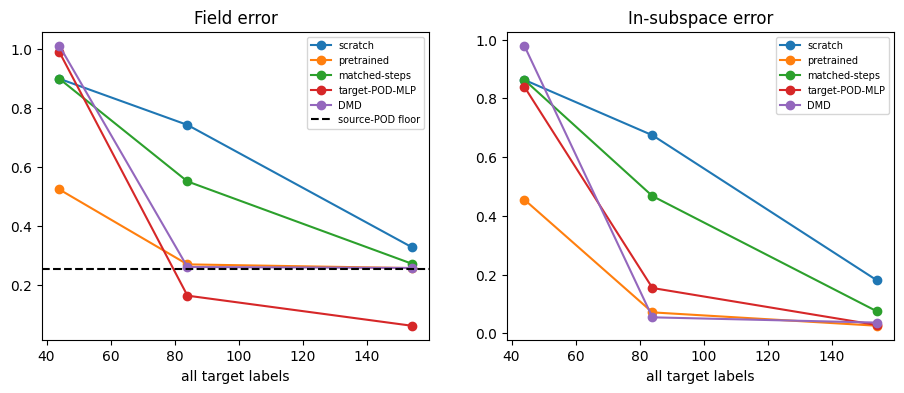

In [4]:
retained=np.load(EVIDENCE/'predictions.npz',allow_pickle=False)
row=next(r for r in rows if r['arm']=='pretrained' and r['target_re']==110)
pred=lab.prediction(retained,'transfer__'+row['key'])[50:]
truth=cases[110]['omega'][210:].reshape(71,-1)
score=np.linalg.norm(pred-truth)/np.linalg.norm(truth)
assert abs(score-row['metrics']['field_relative_l2'])<1e-7
print('Recomputed W22 transfer metric:',score)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for arm in ('scratch','pretrained','matched-steps','target-POD-MLP','DMD'):
    subset=[r for r in rows if r['arm']==arm and r['target_re']==110]
    for j,key in enumerate(('field_relative_l2','in_subspace_relative_l2')):
        groups={n:[r['metrics'][key] for r in subset if r['labels']['total_target_labels']==n] for n in (44,84,154)}
        axes[j].plot(list(groups),[np.mean(v) for v in groups.values()],marker='o',label=arm)
floor=next(r['metrics']['representation_floor'] for r in rows if r['target_re']==110 and r['arm']=='pretrained')
axes[0].axhline(floor,color='black',linestyle='--',label='source-POD floor')
for ax,title in zip(axes,['Field error','In-subspace error']):ax.set_title(title);ax.set_xlabel('all target labels');ax.legend(fontsize=7)
plt.show()

## Task 1: Audit information budgets

Return the cardinality of the union of all target frames used before scoring.

In [5]:
def label_count(record):
    return len(set(record["training_frames"])|set(record["validation_frames"])|set(record["initialization_frames"]))

In [6]:
if RUN_EXERCISES:
    assert label_count(lab.transfer_indices(4)[2])==44
    task_status[1]=True
else:
    task_status[1]=False
print("Task 1:","PASS" if task_status[1] else "NOT SUBMITTED")

Task 1: PASS


## Task 2: Match compute accounting

Count source pretraining and target adaptation steps for each learned arm, without charging source cost to a source-free arm.

In [7]:
def total_steps(adapt,pretrain=None):
    return adapt["executed_steps"]+(pretrain["executed_steps"] if pretrain else 0)

In [8]:
if RUN_EXERCISES:
    assert total_steps({"executed_steps":300},{"executed_steps":300})==600
    task_status[2]=True
else:
    task_status[2]=False
print("Task 2:","PASS" if task_status[2] else "NOT SUBMITTED")

Task 2: PASS


## Task 3: Detect a representation-limited result

Flag cases where the squared representation error explains more than 95% of squared field error. Do not subtract unsquared norms.

In [9]:
def representation_limited(metrics):
    return metrics["representation_floor"]**2/max(metrics["field_relative_l2"]**2,1e-20)>.95

In [10]:
if RUN_EXERCISES:
    assert representation_limited({"representation_floor":.2559,"field_relative_l2":.256})
    task_status[3]=True
else:
    task_status[3]=False
print("Task 3:","PASS" if task_status[3] else "NOT SUBMITTED")

Task 3: PASS


## Task 4: Write a bounded comparative claim

Compute the relative reduction in in-subspace error against the matched-step control. A negative value is negative transfer and must be retained.

In [11]:
def transfer_gain(pretrained,control):
    return 1-pretrained/control

In [12]:
if RUN_EXERCISES:
    assert transfer_gain(.02,.01)==-1
    assert transfer_gain(.01,.02)==.5
    task_status[4]=True
else:
    task_status[4]=False
print("Task 4:","PASS" if task_status[4] else "NOT SUBMITTED")

Task 4: PASS


## Interpretation and submission

Submit the four completed functions, the requested plots/tables, and a 300-word claim ledger. Distinguish observations, fitted quantities, independent evaluation and unsupported extrapolation. Retain failed seeds. Use the lecture source for the rubric and assumptions.

In [13]:
print("Coding tasks passed:",sum(task_status.values()),"/",len(task_status))
assert all(task_status.values())
workspace.cleanup()

Coding tasks passed: 4 / 4
